> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 20. Clustering

*Scope:* Finding structure with no labels to check against — four algorithms with genuinely different notions of what a cluster is.

Every chapter from 11 to 19 had a target column and a score to check against. This one does not.

That single change removes the safety net. There is no training error to minimize, no held-out set that
settles an argument, and — most uncomfortably — **no way to be sure the answer is wrong**. A clustering
algorithm always returns clusters, on any data, including data with no structure at all.

This chapter covers four algorithms with genuinely different ideas of what a cluster *is*, and then 20.8
confronts the evaluation problem directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80
print("ready")

ready


### 20.1 What Unsupervised Learning Asks

1.3 divided learning by what the training data contains. Here it contains $X$ and nothing else, and the
question changes from *"what is the label?"* to *"what structure is present?"*.

| | Supervised (Ch. 11–19) | Clustering |
|---|---|---|
| Data | $X$ **and** $y$ | $X$ only |
| Goal | Predict $y$ for new rows | Describe groups within $X$ |
| Correct answer | Exists, and is in the test set | **Does not exist** |
| Evaluation | A metric against ground truth (Ch. 8) | Internal heuristics, or none (20.8) |
| Output | A prediction | A **group number**, with no name and no meaning |

The last row causes more trouble in practice than anything else in this chapter. A clustering returns
integers; deciding that cluster 2 is "high-value churn risks" is human interpretation done afterwards, and
it is not validated by anything the algorithm did.

In [2]:
X_demo, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=RANDOM_STATE)

labels = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X_demo)

print("the algorithm never saw y_true; it returns group numbers only:")
print("  labels found:", np.unique(labels))
print("  group sizes :", np.bincount(labels))
print("\ncross-tabulation against the true groups:")
print(pd.crosstab(pd.Series(y_true, name="true"), pd.Series(labels, name="cluster")))

the algorithm never saw y_true; it returns group numbers only:
  labels found: [0 1 2]
  group sizes : [100 100 100]

cross-tabulation against the true groups:
cluster    0    1    2
true                  
0        100    0    0
1          0    0  100
2          0  100    0


The recovery is essentially perfect — and note that cluster 0 corresponds to true group 1, cluster 1 to
true group 0. **The numbering carries no information.** Any evaluation that compares cluster labels to
class labels directly (accuracy, say) would report near-zero here, which is why 20.8 uses measures that are
invariant to relabelling.

**The harder problem: clustering never refuses.** Give it data with no groups and it will still partition
it.

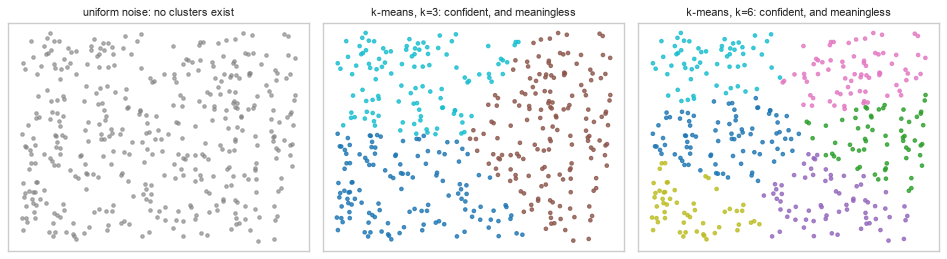

In [3]:
X_uniform = rng.uniform(0, 10, (400, 2))          # no structure whatsoever

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].scatter(X_uniform[:, 0], X_uniform[:, 1], s=10, alpha=0.6, c="gray")
axes[0].set_title("uniform noise: no clusters exist", fontsize=10)

for ax, k in ((axes[1], 3), (axes[2], 6)):
    lbl = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_uniform)
    ax.scatter(X_uniform[:, 0], X_uniform[:, 1], c=lbl, cmap="tab10", s=10, alpha=0.8)
    ax.set_title(f"k-means, k={k}: confident, and meaningless", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

Both partitions look plausible. Neither means anything. **Before interpreting any clustering, establish
that the data has cluster structure at all** — 20.8.3 gives a test for exactly this.

### 20.2 k-Means from Scratch

k-means partitions the data into $K$ groups by minimizing the **within-cluster sum of squares**, also
called inertia:

$$J = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \lVert \mathbf{x} - \boldsymbol{\mu}_k \rVert^2$$

where $\boldsymbol{\mu}_k$ is the mean of cluster $C_k$. Minimizing this exactly is NP-hard, so **Lloyd's
algorithm** alternates two steps that each reduce $J$:

```text
initialize K centroids
repeat:
    assign   : each point joins the cluster of its nearest centroid
    update   : each centroid moves to the mean of its assigned points
until the assignments stop changing
```

Each step can only lower $J$ — assignment because every point moves to a nearer centre, update because the
mean minimizes squared distance — so the algorithm always converges. It converges to a **local** minimum,
which 20.3 shows is a practical problem rather than a theoretical footnote.

In [4]:
def kmeans_from_scratch(X, k, max_iter=300, tol=1e-6, seed=0):
    """Lloyd's algorithm with k-means++ initialization (20.2.1)."""
    centroids = kmeans_plusplus_init(X, k, seed)
    history = []

    for iteration in range(max_iter):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = distances.argmin(axis=1)                      # ASSIGN

        inertia = (distances[np.arange(len(X)), labels] ** 2).sum()
        history.append(inertia)

        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])                                                      # UPDATE

        if np.linalg.norm(new_centroids - centroids) < tol:
            centroids = new_centroids
            break
        centroids = new_centroids

    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = distances.argmin(axis=1)
    inertia = (distances[np.arange(len(X)), labels] ** 2).sum()
    return labels, centroids, inertia, history

#### 20.2.1 k-means++ initialization

Random starting centroids frequently land badly — two in the same true cluster, none in another — and
Lloyd's algorithm cannot recover, because it only ever moves centroids to local means.

**k-means++** spreads the initial centroids out: pick the first at random, then pick each subsequent one
with probability proportional to its **squared distance** from the nearest centroid already chosen.

In [5]:
def kmeans_plusplus_init(X, k, seed=0):
    gen = np.random.default_rng(seed)
    centroids = [X[gen.integers(len(X))]]                        # first one, uniformly at random

    for _ in range(k - 1):
        d2 = np.min(np.linalg.norm(X[:, None, :] - np.array(centroids)[None, :, :], axis=2) ** 2,
                    axis=1)
        probabilities = d2 / d2.sum()                             # far points are far likelier
        centroids.append(X[gen.choice(len(X), p=probabilities)])

    return np.array(centroids)


X_k, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.1, random_state=RANDOM_STATE)

random_init = X_k[np.random.default_rng(3).choice(len(X_k), 4, replace=False)]
pp_init = kmeans_plusplus_init(X_k, 4, seed=3)

print("pairwise distances between the 4 initial centroids:")
for name, init in (("random", random_init), ("k-means++", pp_init)):
    d = np.linalg.norm(init[:, None, :] - init[None, :, :], axis=2)
    print(f"  {name:<11} min {d[d > 0].min():>6.2f}   mean {d[d > 0].mean():>6.2f}")

pairwise distances between the 4 initial centroids:
  random      min   1.27   mean   9.92
  k-means++   min   5.77   mean  14.13


In [6]:
labels_mine, centroids_mine, inertia_mine, history = kmeans_from_scratch(X_k, 4, seed=RANDOM_STATE)

print(f"converged in {len(history)} iterations")
print(f"final inertia: {inertia_mine:.4f}")
print(f"inertia by iteration: {np.array(history[:6]).round(1)} ...")
print(f"\nmonotonically decreasing: {all(np.diff(history) <= 1e-9)}")

converged in 4 iterations
final inertia: 1148.1573
inertia by iteration: [4166.4 1959.4 1176.1 1148.2] ...

monotonically decreasing: True


**Step 4 of the contract.**

In [7]:
sk = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X_k)

print(f"from scratch inertia : {inertia_mine:.6f}")
print(f"scikit-learn inertia : {sk.inertia_:.6f}")
print(f"\nrelative difference  : {abs(inertia_mine - sk.inertia_) / sk.inertia_:.2e}")

# Labels are arbitrary integers, so compare the PARTITION, not the numbers (20.1).
from sklearn.metrics import adjusted_rand_score
print(f"partitions identical : {adjusted_rand_score(labels_mine, sk.labels_) == 1.0}")

from scratch inertia : 1148.157315
scikit-learn inertia : 1148.157315

relative difference  : 0.00e+00
partitions identical : True


The inertia matches and the partitions are identical — but note how the comparison had to be made.
**Comparing the label arrays directly would have failed**, because scikit-learn numbers its clusters in a
different order. The adjusted Rand index (20.8.2) is invariant to relabelling, which is exactly why it is
the right tool here.

In [8]:
print("raw label arrays disagree:")
print(f"  mine   : {labels_mine[:12]}")
print(f"  sklearn: {sk.labels_[:12]}")
print(f"  naive equality: {np.mean(labels_mine == sk.labels_):.1%} 'agreement'")
print(f"  adjusted Rand : {adjusted_rand_score(labels_mine, sk.labels_):.1f}  <- the truth")

raw label arrays disagree:
  mine   : [1 2 3 0 2 2 1 2 3 2 3 0]
  sklearn: [1 2 0 3 2 2 1 2 0 2 0 3]
  naive equality: 50.0% 'agreement'
  adjusted Rand : 1.0  <- the truth


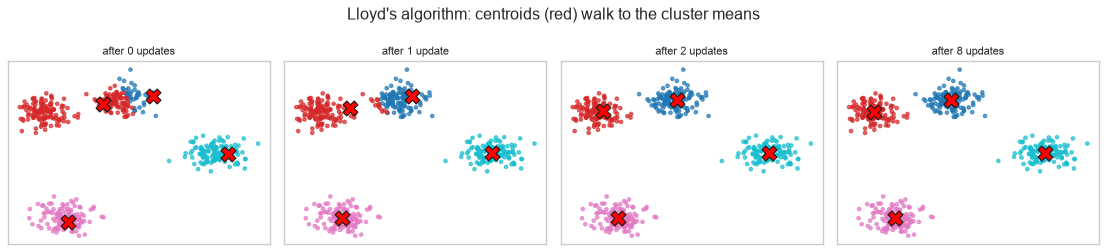

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
centroids = kmeans_plusplus_init(X_k, 4, seed=RANDOM_STATE)

for ax, step in zip(axes, (0, 1, 2, 8)):
    c = centroids.copy()
    for _ in range(step):
        d = np.linalg.norm(X_k[:, None, :] - c[None, :, :], axis=2)
        lbl = d.argmin(axis=1)
        c = np.array([X_k[lbl == j].mean(axis=0) if np.any(lbl == j) else c[j] for j in range(4)])
    d = np.linalg.norm(X_k[:, None, :] - c[None, :, :], axis=2)
    lbl = d.argmin(axis=1)
    ax.scatter(X_k[:, 0], X_k[:, 1], c=lbl, cmap="tab10", s=10, alpha=0.7)
    ax.scatter(c[:, 0], c[:, 1], c="red", marker="X", s=180, edgecolor="k", linewidth=1)
    ax.set_title(f"after {step} update{'s' if step != 1 else ''}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Lloyd's algorithm: centroids (red) walk to the cluster means")
fig.tight_layout()
plt.show()

### 20.3 k-Means in scikit-learn, and Choosing k

| Argument | Is | Default |
|---|---|---|
| `n_clusters` | $K$ — you must supply it (20.3.2) | `8` |
| `init` | `"k-means++"` or `"random"` | `"k-means++"` |
| `n_init` | How many restarts to run, keeping the best | `"auto"` |
| `max_iter` | Iteration cap per restart | `300` |
| `random_state` | Seeds the initialization — **required** for reproducibility | `None` |

#### 20.3.1 Why `n_init` exists

The objective is **non-convex** (10.3), so different initializations reach different local minima. `n_init`
runs the whole algorithm several times and keeps the lowest-inertia result.

In [10]:
X_hard, _ = make_blobs(n_samples=400, centers=6, cluster_std=1.3, random_state=7)

inertias = []
for seed in range(25):
    km = KMeans(n_clusters=6, n_init=1, init="random", random_state=seed).fit(X_hard)
    inertias.append(km.inertia_)

inertias = np.array(inertias)
print(f"25 single random starts on identical data:")
print(f"  best  inertia: {inertias.min():.1f}")
print(f"  worst inertia: {inertias.max():.1f}   ({inertias.max() / inertias.min():.2f}x the best)")
print(f"  distinct local minima found: {len(np.unique(inertias.round(3)))}")

best = KMeans(n_clusters=6, n_init=25, random_state=RANDOM_STATE).fit(X_hard)
print(f"\nn_init=25 with k-means++: {best.inertia_:.1f}")

25 single random starts on identical data:
  best  inertia: 1247.1
  worst inertia: 4258.6   (3.41x the best)
  distinct local minima found: 12



n_init=25 with k-means++: 1247.1


**Common mistake — `n_init=1` to save time.** It is the one parameter here that silently produces a worse
answer rather than a slower one. The cost is linear and the failure is invisible, because a bad local
minimum still returns clusters that look reasonable.

#### 20.3.2 Choosing k

$K$ is an input, not something the algorithm discovers. Three standard approaches, none authoritative:

| Method | Looks for | Weakness |
|---|---|---|
| **Elbow** | The bend where inertia stops dropping sharply | Often no clear bend; judged by eye |
| **Silhouette** | The $K$ maximizing mean silhouette (20.8.1) | Biased towards convex, balanced clusters |
| **Gap statistic** | The largest gap vs. clustered uniform noise | Expensive; needs reference simulations |
| **Domain knowledge** | The number the business can act on | **Usually the best answer** |

In [11]:
from sklearn.metrics import silhouette_score

X_elbow, y_elbow = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=RANDOM_STATE)

ks = range(2, 11)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_elbow)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X_elbow, km.labels_)})

table = pd.DataFrame(rows)
table["inertia drop"] = -table["inertia"].diff()
print(table.round(3).to_string(index=False))
print(f"\ntrue number of groups: 4")
print(f"silhouette picks     : {table.loc[table['silhouette'].idxmax(), 'k']}")

 k   inertia  silhouette  inertia drop
 2 15737.084       0.596           NaN
 3  3426.257       0.761     12310.826
 4   948.890       0.791      2477.367
 5   856.472       0.663        92.418
 6   768.039       0.561        88.433
 7   681.352       0.441        86.687
 8   608.538       0.337        72.814
 9   546.791       0.347        61.747
10   497.991       0.348        48.799

true number of groups: 4
silhouette picks     : 4


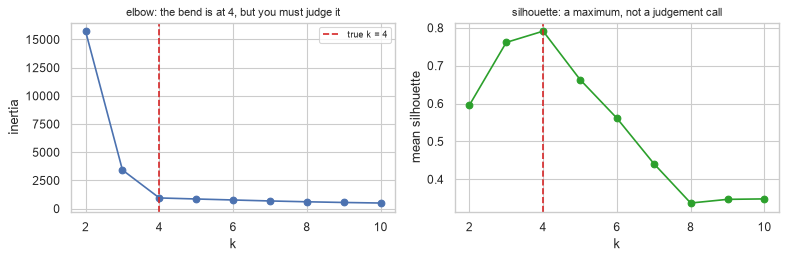

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(table["k"], table["inertia"], "o-")
axes[0].axvline(4, color="tab:red", ls="--", label="true k = 4")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[0].set_title("elbow: the bend is at 4, but you must judge it", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(table["k"], table["silhouette"], "o-", color="tab:green")
axes[1].axvline(4, color="tab:red", ls="--")
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean silhouette")
axes[1].set_title("silhouette: a maximum, not a judgement call", fontsize=10)

fig.tight_layout()
plt.show()

**Inertia always decreases with $K$** — at $K = n$ every point is its own cluster and inertia is zero — so
it can never be maximized or minimized to choose $K$. Only the *shape* of the curve carries information,
which is what makes the elbow method a judgement call rather than a calculation.

In [13]:
extreme = pd.DataFrame([
    {"k": k, "inertia": KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE)
     .fit(X_elbow).inertia_}
    for k in (2, 4, 50, 200, 499)
])
print(extreme.round(2).to_string(index=False))
print("\ninertia is monotone in k; 'minimize inertia' would always answer k = n.")

  k  inertia
  2 15737.08
  4   948.89
 50    95.50
200     8.05
499     0.00

inertia is monotone in k; 'minimize inertia' would always answer k = n.


### 20.4 Where k-Means Fails

k-means minimizes squared distance to a centroid. That single fact implies every one of its failure modes.

| Assumption baked into the objective | Fails when |
|---|---|
| Clusters are **spherical** | Groups are elongated or curved |
| Clusters have **similar variance** | One group is tight, another diffuse |
| Clusters have **similar size** | One group has ten times the members |
| Every point **belongs** somewhere | Outliers and noise exist |
| Distance is meaningful | Features are unscaled (5.5) or high-dimensional (7.1) |

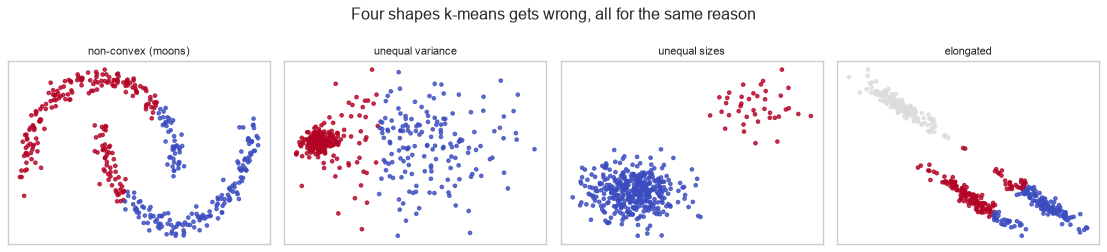

In [14]:
def two_moons():
    return make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)[0]

def unequal_variance():
    a = rng.normal([0, 0], 0.4, (200, 2))
    b = rng.normal([4, 0], 1.8, (200, 2))
    return np.vstack([a, b])

def unequal_size():
    a = rng.normal([0, 0], 0.7, (400, 2))
    b = rng.normal([4, 4], 0.7, (40, 2))
    return np.vstack([a, b])

def elongated():
    """Three blobs, then sheared - the clusters are now tilted ellipses."""
    X, y = make_blobs(n_samples=450, centers=3, cluster_std=1.5, random_state=RANDOM_STATE)
    return X @ np.array([[0.61, -0.64], [-0.41, 0.85]]), y


cases = {"non-convex (moons)": (two_moons(), 2),
         "unequal variance": (unequal_variance(), 2),
         "unequal sizes": (unequal_size(), 2),
         "elongated": (elongated()[0], 3)}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (name, (Xf, k)) in zip(axes, cases.items()):
    lbl = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xf)
    ax.scatter(Xf[:, 0], Xf[:, 1], c=lbl, cmap="coolwarm", s=10, alpha=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Four shapes k-means gets wrong, all for the same reason")
fig.tight_layout()
plt.show()

In every panel the boundary is a straight line equidistant between two centroids — that is the only kind of
boundary k-means can draw. It is, in effect, a **Voronoi partition** of the space.

**Scaling is not optional**, for the same reason as k-NN (14.7.1): the distance is a sum over features, so
the largest-range feature dominates.

In [15]:
from sklearn.metrics import adjusted_rand_score

n_s = 400
truth = np.r_[np.zeros(n_s // 2), np.ones(n_s // 2)].astype(int)

# The real structure lives in `informative`: two well-separated groups, sd 0.5, centres +-3.
informative = np.r_[rng.normal(-3, 0.5, n_s // 2), rng.normal(3, 0.5, n_s // 2)]
# `loud` carries no structure at all - it is pure noise, but 500x the scale.
loud = rng.normal(0, 500, n_s)

X_scale = np.column_stack([informative, loud])

raw = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_scale)
scaled = KMeans(n_clusters=2, n_init=10,
                random_state=RANDOM_STATE).fit_predict(StandardScaler().fit_transform(X_scale))

print(f"adjusted Rand vs the truth, unscaled : {adjusted_rand_score(truth, raw):.4f}")
print(f"adjusted Rand vs the truth, scaled   : {adjusted_rand_score(truth, scaled):.4f}")

adjusted Rand vs the truth, unscaled : -0.0016
adjusted Rand vs the truth, scaled   : 1.0000


### 20.5 Hierarchical Clustering

Rather than committing to $K$ up front, **agglomerative** clustering builds a tree: start with every point
as its own cluster, repeatedly merge the two closest, and stop when one cluster remains. The result is a
**dendrogram** that can be cut at any height.

The definition of "closest between two clusters" is the **linkage criterion**, and it changes the answer
completely.

| Linkage | Distance between clusters | Produces | Sensitive to |
|---|---|---|---|
| **Single** | Closest pair of points | Long, chained clusters | Noise — one bridge merges two groups |
| **Complete** | Farthest pair of points | Compact, similar-diameter clusters | Outliers |
| **Average** | Mean over all pairs | A compromise | — |
| **Ward** | Increase in within-cluster variance | Similar-size spherical clusters | Like k-means; the default |

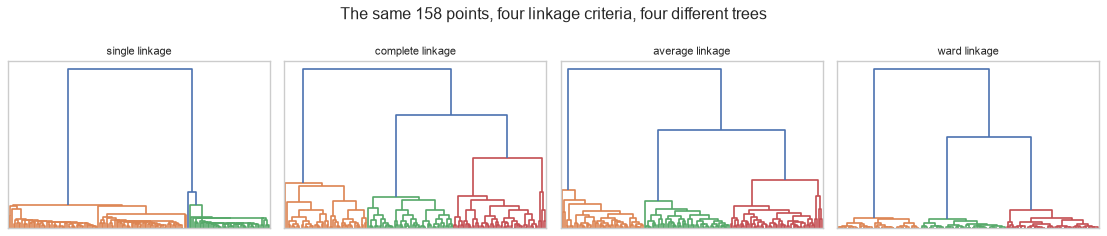

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage

X_blobs, y_blobs = make_blobs(n_samples=150, centers=3, cluster_std=0.9,
                              random_state=RANDOM_STATE)

# Eight points scattered along the line between two of the centres. Eight points out of
# 158 - a rounding error in any summary statistic, and enough to change the answer below.
c0, c1 = X_blobs[y_blobs == 0].mean(axis=0), X_blobs[y_blobs == 1].mean(axis=0)
bridge = c0 + np.linspace(0.1, 0.9, 8)[:, None] * (c1 - c0) + rng.normal(0, 0.3, (8, 2))

X_h = np.vstack([X_blobs, bridge])
y_h = np.r_[y_blobs, np.full(8, -1)]                          # bridge points have no true group

fig, axes = plt.subplots(1, 4, figsize=(14, 3.0))
for ax, method in zip(axes, ("single", "complete", "average", "ward")):
    Z = linkage(X_h, method=method)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=Z[-2, 2])
    ax.set_title(f"{method} linkage", fontsize=10)
    ax.set_yticks([])
fig.suptitle("The same 158 points, four linkage criteria, four different trees")
fig.tight_layout()
plt.show()

In [17]:
real = y_h >= 0                                               # score on the 150 real points only

print(f"{'linkage':>10}{'ARI vs truth':>15}{'cluster sizes':>22}")
for method in ("single", "complete", "average", "ward"):
    lbl = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(X_h)
    print(f"{method:>10}{adjusted_rand_score(y_h[real], lbl[real]):>15.4f}"
          f"{str(np.bincount(lbl)):>22}")

   linkage   ARI vs truth         cluster sizes
    single         0.5584         [108  49   1]
  complete         1.0000            [56 50 52]
   average         1.0000            [56 50 52]
      ward         1.0000            [56 50 52]


**Single linkage's chaining is its defining behaviour**, and it is both a weakness and the reason it exists.
Eight bridge points — 5% of the data — are enough to make it merge two genuinely separate blobs, because it
only ever asks about the *closest* pair, and a chain of near neighbours crosses the gap. The other three
linkages ask about the farthest pair or the variance, so the bridge does not persuade them.

The same behaviour is an advantage on elongated or curved shapes, where following a path of near neighbours
is exactly right and demanding compactness is exactly wrong.

In [18]:
X_moons = make_moons(n_samples=300, noise=0.05, random_state=RANDOM_STATE)[0]
y_moons = make_moons(n_samples=300, noise=0.05, random_state=RANDOM_STATE)[1]

print(f"{'method':>22}{'ARI on moons':>15}")
for method in ("ward", "complete", "average", "single"):
    lbl = AgglomerativeClustering(n_clusters=2, linkage=method).fit_predict(X_moons)
    print(f"{method + ' linkage':>22}{adjusted_rand_score(y_moons, lbl):>15.4f}")
print(f"{'k-means':>22}{adjusted_rand_score(y_moons, KMeans(2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_moons)):>15.4f}")

                method   ARI on moons
          ward linkage         0.5169
      complete linkage         0.3994
       average linkage         0.3117
        single linkage         1.0000


               k-means         0.2475


Single linkage recovers the moons perfectly where every compactness-based method fails. The chaining that
ruins it on blobs is exactly what lets it follow a crescent.

#### 20.5.1 Cutting the dendrogram

The tree does not choose $K$ — it defers the choice. Cutting at a height gives a clustering; the large
vertical gaps are the natural places to cut.

In [19]:
Z = linkage(X_h, method="ward")
merge_heights = Z[:, 2]
gaps = np.diff(merge_heights)

print("the largest merge-height gaps (where the tree is 'reluctant' to merge):")
for rank, idx in enumerate(np.argsort(gaps)[::-1][:3], start=1):
    clusters_after = len(X_h) - idx - 1
    print(f"  {rank}. gap {gaps[idx]:>6.2f} between merges -> cutting here gives "
          f"{clusters_after} clusters")

the largest merge-height gaps (where the tree is 'reluctant' to merge):
  1. gap  55.81 between merges -> cutting here gives 3 clusters
  2. gap  51.37 between merges -> cutting here gives 2 clusters
  3. gap   5.82 between merges -> cutting here gives 4 clusters


### 20.6 DBSCAN

k-means and hierarchical clustering assign **every** point to a cluster. DBSCAN does not, and that is its
central idea: clusters are **dense regions separated by sparse ones**, and points in the sparse regions are
labelled noise.

Two parameters define density:

| Parameter | Is |
|---|---|
| `eps` | The radius of a point's neighbourhood |
| `min_samples` | How many points must be within `eps` for a point to be a **core point** |

| Point type | Definition |
|---|---|
| **Core** | Has at least `min_samples` neighbours within `eps` |
| **Border** | Within `eps` of a core point, but not core itself |
| **Noise** | Neither — labelled `-1` |

The consequences are large: DBSCAN **finds the number of clusters itself**, handles arbitrary shapes, and
is the only algorithm here with a built-in notion of an outlier.

In [20]:
X_db, y_db = make_moons(n_samples=400, noise=0.07, random_state=RANDOM_STATE)
X_db = np.vstack([X_db, rng.uniform(-1.5, 2.5, (40, 2))])      # add 40 noise points

db = DBSCAN(eps=0.2, min_samples=5).fit(X_db)
labels_db = db.labels_

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f"clusters found : {n_clusters}   (never specified)")
print(f"noise points   : {(labels_db == -1).sum()} of {len(X_db)}")
print(f"core points    : {len(db.core_sample_indices_)}")
print(f"border points  : {len(X_db) - len(db.core_sample_indices_) - (labels_db == -1).sum()}")

clusters found : 2   (never specified)
noise points   : 25 of 440
core points    : 409
border points  : 6


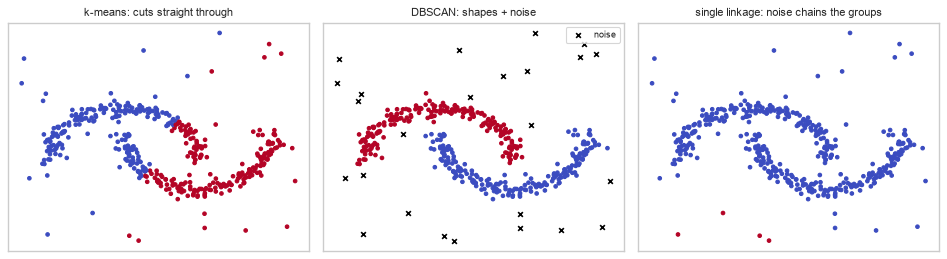

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

km_lbl = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_db)
axes[0].scatter(X_db[:, 0], X_db[:, 1], c=km_lbl, cmap="coolwarm", s=10)
axes[0].set_title("k-means: cuts straight through", fontsize=10)

noise = labels_db == -1
axes[1].scatter(X_db[~noise, 0], X_db[~noise, 1], c=labels_db[~noise], cmap="coolwarm", s=10)
axes[1].scatter(X_db[noise, 0], X_db[noise, 1], c="black", marker="x", s=18, label="noise")
axes[1].set_title("DBSCAN: shapes + noise", fontsize=10)
axes[1].legend(fontsize=8)

single_lbl = AgglomerativeClustering(n_clusters=2, linkage="single").fit_predict(X_db)
axes[2].scatter(X_db[:, 0], X_db[:, 1], c=single_lbl, cmap="coolwarm", s=10)
axes[2].set_title("single linkage: noise chains the groups", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

The third panel is the important contrast. Single linkage also handles crescents (20.5), but the 40 noise
points give it a bridge to chain across — and it has no way to refuse them. DBSCAN's ability to say
"this point is not in any cluster" is what makes it robust here.

#### 20.6.1 Choosing `eps`

`eps` is the parameter that matters and it is sensitive. The standard heuristic: plot each point's distance
to its $k$-th nearest neighbour, sorted, and look for the knee.

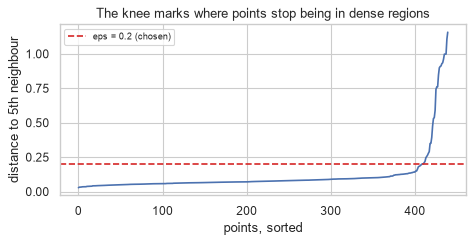

In [22]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5
distances, _ = NearestNeighbors(n_neighbors=min_samples).fit(X_db).kneighbors(X_db)
kth_distance = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(kth_distance)
ax.axhline(0.2, color="tab:red", ls="--", label="eps = 0.2 (chosen)")
ax.set_xlabel("points, sorted"); ax.set_ylabel(f"distance to {min_samples}th neighbour")
ax.set_title("The knee marks where points stop being in dense regions")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [23]:
print(f"{'eps':>7}{'clusters':>11}{'noise':>8}{'ARI vs moons':>15}")
y_db_full = np.r_[y_db, np.full(40, -1)]                      # true labels, noise marked -1
for eps in (0.08, 0.12, 0.20, 0.30, 0.50):
    lbl = DBSCAN(eps=eps, min_samples=5).fit_predict(X_db)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"{eps:>7.2f}{n_c:>11}{(lbl == -1).sum():>8}{adjusted_rand_score(y_db_full, lbl):>15.4f}")

    eps   clusters   noise   ARI vs moons
   0.08         17     101         0.1066
   0.12          2      38         0.9315
   0.20          2      25         0.9186
   0.30          1      20         0.1145
   0.50          1      14         0.0778


**Common mistake — treating DBSCAN as parameter-free because it infers $K$.** It does not need $K$, but it
needs `eps`, and the table above shows `eps` controlling the cluster count anyway. The choice has simply
moved, not disappeared. `eps` is also in the units of the features, so **DBSCAN requires scaling** even
more obviously than k-means does.

### 20.7 Gaussian Mixture Models

k-means assigns each point to exactly one cluster — a **hard** assignment. A Gaussian mixture model fits
$K$ Gaussian distributions and reports the **probability** that each point came from each one.

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \Sigma_k)$$

with mixing weights $\pi_k$ summing to 1. Fitting uses **expectation-maximization**, which is Lloyd's
algorithm generalized:

| | k-means | GMM (EM) |
|---|---|---|
| E-step | Assign to nearest centroid | Compute each point's **responsibility** for each component |
| M-step | Move centroid to the mean | Update $\pi_k$, $\boldsymbol{\mu}_k$ **and $\Sigma_k$** |
| Cluster shape | Spherical, equal size | **Ellipsoidal, any orientation** |
| Assignment | Hard | **Soft** |

The covariance matrix $\Sigma_k$ is what buys the flexibility — it lets a cluster be elongated and tilted,
which 20.4 showed k-means cannot represent.

In [24]:
X_gmm, truth_gmm = elongated()                                 # 3 sheared blobs, from 20.4

km_lbl = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X_gmm)
gmm = GaussianMixture(n_components=3, covariance_type="full", n_init=5,
                      random_state=RANDOM_STATE).fit(X_gmm)
gmm_lbl = gmm.predict(X_gmm)

print(f"ARI vs truth, k-means : {adjusted_rand_score(truth_gmm, km_lbl):.4f}")
print(f"ARI vs truth, GMM     : {adjusted_rand_score(truth_gmm, gmm_lbl):.4f}")

ARI vs truth, k-means : 0.6734
ARI vs truth, GMM     : 1.0000


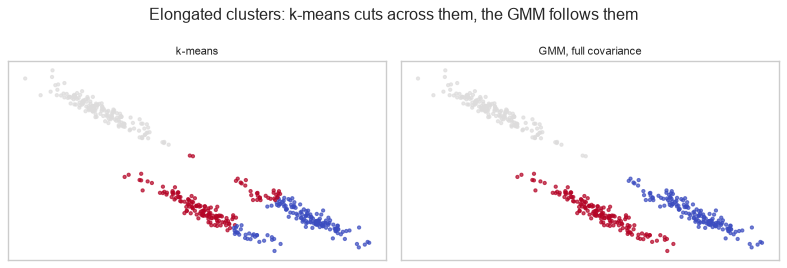

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, (name, lbl) in zip(axes, (("k-means", km_lbl), ("GMM, full covariance", gmm_lbl))):
    ax.scatter(X_gmm[:, 0], X_gmm[:, 1], c=lbl, cmap="coolwarm", s=8, alpha=0.7)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Elongated clusters: k-means cuts across them, the GMM follows them")
fig.tight_layout()
plt.show()

**Soft assignment** is the second advantage, and it makes uncertainty visible: points between components
get split responsibilities, which a hard assignment hides entirely. The sheared blobs above are too well
separated to show this, so here are two components that genuinely overlap.

In [26]:
X_soft = np.vstack([rng.normal([0, 0], 1.0, (300, 2)),
                    rng.normal([2, 0], 1.0, (300, 2))])        # centres 2 apart, sd 1 - overlapping

gmm_soft = GaussianMixture(n_components=2, covariance_type="full", n_init=5,
                           random_state=RANDOM_STATE).fit(X_soft)
proba = gmm_soft.predict_proba(X_soft)
confidence = proba.max(axis=1)

print(f"points assigned with >99% confidence : {(confidence > 0.99).mean():.1%}")
print(f"points genuinely ambiguous (<70%)    : {(confidence < 0.70).mean():.1%}")

print("\nthe three least certain points:")
for i in np.argsort(confidence)[:3]:
    print(f"  responsibilities {proba[i].round(3)}")

points assigned with >99% confidence : 18.2%
points genuinely ambiguous (<70%)    : 16.8%

the three least certain points:
  responsibilities [0.497 0.503]
  responsibilities [0.505 0.495]
  responsibilities [0.511 0.489]


Fewer than one point in five is assigned with near-certainty, and about one in six is genuinely undecided —
and a hard clustering would have handed every one of those a definite cluster number anyway. **That is the
information k-means discards.** If the downstream decision is "send this customer the retention offer", the
difference between a 0.95 and a 0.51 membership is exactly what you need and exactly what a hard label
destroys.

`covariance_type` controls how much shape freedom each component gets, and it is the main
bias–variance knob (9.2).

| `covariance_type` | Each component | Parameters per component |
|---|---|---|
| `"spherical"` | One variance — a circle | 1 |
| `"diag"` | Axis-aligned ellipse | $p$ |
| `"tied"` | All components share one full matrix | $p(p+1)/2$, shared |
| `"full"` | Any ellipse, any orientation | $p(p+1)/2$ |

Because a GMM is a genuine probabilistic model, it has a **likelihood** — which means $K$ can be chosen by
an information criterion rather than by eye (20.3.2's problem, finally solved properly).

In [27]:
X_bic, y_bic = make_blobs(n_samples=600, centers=4, cluster_std=1.0, random_state=RANDOM_STATE)

rows = []
for k in range(1, 9):
    g = GaussianMixture(n_components=k, covariance_type="full",
                        random_state=RANDOM_STATE).fit(X_bic)
    rows.append({"k": k, "log likelihood": g.score(X_bic) * len(X_bic),
                 "BIC": g.bic(X_bic), "AIC": g.aic(X_bic)})

bic_table = pd.DataFrame(rows)
print(bic_table.round(1).to_string(index=False))
print(f"\ntrue k = 4")
print(f"BIC picks k = {bic_table.loc[bic_table['BIC'].idxmin(), 'k']}")
print(f"AIC picks k = {bic_table.loc[bic_table['AIC'].idxmin(), 'k']}")

 k  log likelihood    BIC    AIC
 1         -3791.8 7615.6 7593.6
 2         -3082.5 6235.3 6186.9
 3         -2683.0 5474.8 5400.0
 4         -2510.4 5167.9 5066.8
 5         -2507.0 5199.4 5071.9
 6         -2504.4 5232.7 5078.8
 7         -2504.2 5270.6 5090.3
 8         -2499.4 5299.4 5092.8

true k = 4
BIC picks k = 4
AIC picks k = 4


**BIC penalizes parameters more heavily than AIC**, so BIC tends to choose simpler models. Unlike inertia,
both have a genuine minimum — the likelihood rises with $K$ but the penalty rises faster, so there is a
real trade-off rather than a monotone curve.

#### 20.7.1 Singular components

The likelihood that makes BIC possible is also the GMM's weak point. If a component ends up covering a
handful of coincident points, its covariance shrinks towards zero, its density at those points goes to
infinity, and so does the log likelihood. The fit does not error — it reports a spectacular score for a
model that has collapsed.

This is not exotic: **duplicate rows are enough**, and real tabular data is full of them (5.4).

In [28]:
X_dup = np.vstack([rng.normal(0, 1, (200, 3)),
                   np.tile(rng.normal(5, 1, (1, 3)), (12, 1))])   # 12 IDENTICAL rows

print(f"{'reg_covar':>11}{'log likelihood':>17}{'BIC':>12}{'min variance':>15}")
for reg in (1e-12, 1e-6, 1e-3):
    g = GaussianMixture(n_components=4, covariance_type="full", reg_covar=reg,
                        n_init=3, random_state=RANDOM_STATE).fit(X_dup)
    min_var = min(np.linalg.eigvalsh(c).min() for c in g.covariances_)
    print(f"{reg:>11.0e}{g.score(X_dup) * len(X_dup):>17.1f}{g.bic(X_dup):>12.1f}{min_var:>15.2e}")

  reg_covar   log likelihood         BIC   min variance


      1e-12           -410.4      1029.7       1.00e-12


      1e-06           -659.1      1527.0       1.00e-06


      1e-03           -783.4      1775.8       1.00e-03


Read the last column first: in every row the smallest covariance eigenvalue sits **exactly on
`reg_covar`**. That is the signature of a collapsed component — the fit drove the covariance as far down as
it was allowed to go, and nothing else. The likelihood it bought is worth hundreds of nats, and BIC, which
only sees the likelihood and the parameter count, rewards it accordingly.

`reg_covar` — scikit-learn's default is `1e-6` — is that floor, and raising it is the standard defence.

**The diagnostic**, and it is cheap: after fitting, check `min(eigvalsh(c).min() for c in
gmm.covariances_)`. If it equals `reg_covar`, a component has collapsed and the BIC for that $K$ means
nothing. A BIC that is badly out of line with its neighbours in $K$ is this, not a discovery — 20.9.1 walks
straight into it on real data.

### 20.8 Evaluating a Clustering

This is the hard part, and it splits cleanly by whether ground truth exists.

| | **Internal** measures | **External** measures |
|---|---|---|
| Need labels | No | **Yes** |
| Measure | Geometric quality of the partition | Agreement with known groups |
| Available in practice | Always | **Almost never** — if you had labels you would not be clustering |
| Examples | Silhouette, Davies–Bouldin, Calinski–Harabasz | ARI, NMI, V-measure |
| Honest use | Comparing $K$ or algorithms on one dataset | Benchmarking and teaching |

#### 20.8.1 Internal measures

The **silhouette** of a point compares its mean distance to its own cluster ($a$) with the mean distance to
the nearest other cluster ($b$):

$$s = \frac{b - a}{\max(a, b)} \in [-1, 1]$$

$s$ near 1 means well separated; near 0 means on a boundary; **negative means the point is closer to
another cluster than its own**.

In [29]:
from sklearn.metrics import (silhouette_samples, silhouette_score,
                             davies_bouldin_score, calinski_harabasz_score)

X_int, y_int = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=RANDOM_STATE)

print(f"{'k':>4}{'silhouette':>13}{'Davies-Bouldin':>17}{'Calinski-Harabasz':>20}")
for k in (2, 3, 4, 5, 7):
    lbl = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_int)
    print(f"{k:>4}{silhouette_score(X_int, lbl):>13.4f}"
          f"{davies_bouldin_score(X_int, lbl):>17.4f}"
          f"{calinski_harabasz_score(X_int, lbl):>20.1f}")
print("\nsilhouette and Calinski-Harabasz: HIGHER is better.  Davies-Bouldin: LOWER is better.")

   k   silhouette   Davies-Bouldin   Calinski-Harabasz


   2       0.5955           0.5196               574.9


   3       0.7613           0.3486              2210.5


   4       0.7911           0.2939              5742.0


   5       0.6633           0.6452              4776.1


   7       0.4415           1.0115              4007.7

silhouette and Calinski-Harabasz: HIGHER is better.  Davies-Bouldin: LOWER is better.


In [30]:
# The per-point silhouette shows WHICH points are badly placed, not just the average.
lbl4 = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_int)
lbl7 = KMeans(n_clusters=7, n_init=10, random_state=RANDOM_STATE).fit_predict(X_int)

for name, lbl in (("k=4", lbl4), ("k=7", lbl7)):
    s = silhouette_samples(X_int, lbl)
    print(f"{name}: mean {s.mean():.4f}   negative silhouettes: {(s < 0).sum()} of {len(s)}")

k=4: mean 0.7911   negative silhouettes: 0 of 500
k=7: mean 0.4415   negative silhouettes: 6 of 500


**Common mistake — trusting the silhouette to compare algorithms.** It rewards compact, well-separated,
convex clusters, which is k-means' objective almost exactly. Using it to judge DBSCAN on crescent-shaped
data penalizes DBSCAN for finding the *right* answer.

In [31]:
X_cmp, y_cmp = make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)

km_cmp = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_cmp)
db_cmp = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_cmp)

print(f"{'method':>10}{'silhouette':>13}{'ARI vs truth':>15}")
for name, lbl in (("k-means", km_cmp), ("DBSCAN", db_cmp)):
    print(f"{name:>10}{silhouette_score(X_cmp, lbl):>13.4f}{adjusted_rand_score(y_cmp, lbl):>15.4f}")
print("\nthe silhouette prefers k-means; the ground truth says DBSCAN is right.")

    method   silhouette   ARI vs truth
   k-means       0.4881         0.2481
    DBSCAN       0.3255         1.0000

the silhouette prefers k-means; the ground truth says DBSCAN is right.


#### 20.8.2 External measures

When labels *are* available — benchmarking, or a subset that has been hand-labelled — the measures must be
invariant to cluster renumbering (20.1).

| Measure | Range | Chance level | Notes |
|---|---|---|---|
| **Adjusted Rand (ARI)** | −1 to 1 | **0** | Corrected for chance; the standard choice |
| **Normalized mutual information (NMI)** | 0 to 1 | > 0 | Not chance-corrected; inflates with many clusters |
| **Adjusted mutual information (AMI)** | ≤ 1 | **0** | NMI, chance-corrected |
| **V-measure** | 0 to 1 | > 0 | Harmonic mean of homogeneity and completeness |

In [32]:
from sklearn.metrics import (adjusted_mutual_info_score, normalized_mutual_info_score,
                             v_measure_score)

random_labels = rng.integers(0, 4, len(y_int))                 # pure noise "clustering"
good_labels = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_int)

print(f"{'labelling':>16}{'ARI':>9}{'AMI':>9}{'NMI':>9}{'V-measure':>12}")
for name, lbl in (("random", random_labels), ("k-means k=4", good_labels)):
    print(f"{name:>16}{adjusted_rand_score(y_int, lbl):>9.4f}"
          f"{adjusted_mutual_info_score(y_int, lbl):>9.4f}"
          f"{normalized_mutual_info_score(y_int, lbl):>9.4f}"
          f"{v_measure_score(y_int, lbl):>12.4f}")

       labelling      ARI      AMI      NMI   V-measure
          random  -0.0034  -0.0037   0.0029      0.0029
     k-means k=4   1.0000   1.0000   1.0000      1.0000


The random row is the reason chance correction matters. ARI and AMI sit at ~0 as they should; NMI and
V-measure report a small positive number for a labelling that is pure noise, and that inflation grows with
the number of clusters.

In [33]:
print("NMI's inflation with cluster count, on RANDOM labels:")
for k in (2, 5, 20, 100):
    noise_labels = rng.integers(0, k, len(y_int))
    print(f"  k={k:>4}   NMI {normalized_mutual_info_score(y_int, noise_labels):.4f}"
          f"   AMI {adjusted_mutual_info_score(y_int, noise_labels):>8.4f}")

NMI's inflation with cluster count, on RANDOM labels:
  k=   2   NMI 0.0039   AMI   0.0010
  k=   5   NMI 0.0037   AMI  -0.0044
  k=  20   NMI 0.0258   AMI  -0.0015
  k= 100   NMI 0.1227   AMI   0.0009


#### 20.8.3 Does the data cluster at all?

20.1 showed k-means partitioning uniform noise. The **Hopkins statistic** tests for cluster tendency before
any clustering is attempted: it compares distances from real points to their neighbours against distances
from uniformly random points to real neighbours.

| Hopkins $H$ | Interpretation |
|---|---|
| ≈ 0.5 | Uniformly distributed — **no cluster structure** |
| → 1.0 | Strongly clustered |
| → 0.0 | Regularly spaced (a grid) |

In [34]:
def hopkins(X, sample_fraction=0.1, seed=0):
    # [seed, 20] rather than seed: default_rng(42) here would replay the very stream
    # that generated X_uniform, and the "random" query points would BE the data points,
    # driving u to zero and the statistic to 0.04. A silent, completely wrong answer.
    gen = np.random.default_rng([seed, 20])
    n = len(X)
    m = max(2, int(sample_fraction * n))

    nn = NearestNeighbors(n_neighbors=2).fit(X)

    # u: distances from uniformly random points in the bounding box to the nearest real point
    lows, highs = X.min(axis=0), X.max(axis=0)
    uniform_points = gen.uniform(lows, highs, (m, X.shape[1]))
    u = nn.kneighbors(uniform_points, n_neighbors=1)[0].ravel()

    # w: distances from real sampled points to their nearest OTHER real point
    idx = gen.choice(n, m, replace=False)
    w = nn.kneighbors(X[idx], n_neighbors=2)[0][:, 1]

    return u.sum() / (u.sum() + w.sum())


for name, Xd in (("uniform noise", X_uniform),
                 ("4 clear blobs", X_int),
                 ("two moons", X_cmp)):
    print(f"{name:<18} Hopkins {hopkins(Xd, seed=RANDOM_STATE):.4f}")

uniform noise      Hopkins 0.5372


4 clear blobs      Hopkins 0.9270
two moons          Hopkins 0.8703


The uniform data scores near 0.5 — correctly reporting that there is nothing to find — while both
structured datasets score far higher. **Run this before clustering, not after**, because afterwards you
will already have clusters to be persuaded by.

### 20.9 In Practice

#### 20.9.1 A worked case: customer segmentation that survives scrutiny

The request: *"Segment our customers so marketing can target them differently."*

Segmentation is the most common commercial use of clustering and the most commonly done badly. The failure
is not technical — it is that a partition gets produced, named, and acted on without anyone establishing
that the groups are real.

In [35]:
DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


data = prepare(pd.read_csv("data/customers.csv"))
FEATURES = ["tenure_months", "monthly_charges", "support_tickets",
            "last_login_days", "satisfaction_score"]

X_seg = data[FEATURES].fillna(data[FEATURES].median())
X_scaled = StandardScaler().fit_transform(X_seg)               # mandatory (20.4)

print(f"{len(X_seg)} customers, {len(FEATURES)} behavioural features")
print("churn is deliberately EXCLUDED - this is segmentation, not prediction")

1000 customers, 5 behavioural features
churn is deliberately EXCLUDED - this is segmentation, not prediction


**Step 1 — before anything else, is there structure to find?** (20.8.3)

In [36]:
h = hopkins(X_scaled, seed=RANDOM_STATE)

# The absolute value is not interpretable on its own: any data with a non-uniform
# marginal distribution scores above 0.5. The null must be built from THIS data -
# every column independently shuffled, which keeps the marginals and destroys only
# the relationships between columns.
shuffled = np.column_stack([rng.permutation(col) for col in X_scaled.T])
h_null = hopkins(shuffled, seed=RANDOM_STATE)

print(f"Hopkins, customer data      : {h:.4f}")
print(f"Hopkins, column-shuffled    : {h_null:.4f}   <- the null")
print(f"excess over the null        : {h - h_null:+.4f}")

Hopkins, customer data      : 0.7725
Hopkins, column-shuffled    : 0.7351   <- the null
excess over the null        : +0.0374


**The excess is small.** The customer data scores barely above a version of itself with every relationship
between features destroyed — so whatever joint structure is present is weak. Compare that with the
separated blobs of 20.8.3, which cleared 0.9.

This is the answer the test exists to give, and it is not the answer anyone wants. It does not mean
stop: a segmentation of a continuum is still useful, because splitting a continuous population into
addressable groups is a legitimate operational act. It means **the language has to change** — these will be
*imposed* segments, not *discovered* ones, and nobody downstream should be told the business has four
natural customer types. 20.9.1's remaining steps are about producing something defensible under that
constraint, and the evidence for it arrives in step 5.

**Step 2 — choose $K$ with several criteria, and distrust a single one.**

In [37]:
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_scaled)
    # reg_covar well above the default, after 20.7.1 - this data has near-duplicate rows.
    gm = GaussianMixture(n_components=k, covariance_type="full", reg_covar=1e-3,
                         n_init=3, random_state=RANDOM_STATE).fit(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, km.labels_),
        "davies_bouldin": davies_bouldin_score(X_scaled, km.labels_),
        "gmm_BIC": gm.bic(X_scaled),
        "min eigval": min(np.linalg.eigvalsh(c).min() for c in gm.covariances_),
    })

choice = pd.DataFrame(rows)
choice["collapsed"] = np.isclose(choice["min eigval"], 1e-3)   # the 20.7.1 diagnostic
print(choice.round(3).to_string(index=False))

usable = choice[~choice["collapsed"]]
print(f"\nsilhouette max at k     = {choice.loc[choice['silhouette'].idxmax(), 'k']}")
print(f"Davies-Bouldin min at k = {choice.loc[choice['davies_bouldin'].idxmin(), 'k']}")
print(f"GMM BIC min, unfiltered = {choice.loc[choice['gmm_BIC'].idxmin(), 'k']}"
      f"   <- a collapsed fit (20.7.1)")
print(f"GMM BIC min, usable k   = {usable.loc[usable['gmm_BIC'].idxmin(), 'k']}")

 k  inertia  silhouette  davies_bouldin   gmm_BIC  min eigval  collapsed
 2 3894.866       0.221           1.732 13514.739       0.267      False
 3 3324.517       0.212           1.636 13566.872       0.226      False
 4 2879.891       0.203           1.495 13646.308       0.227      False
 5 2548.392       0.197           1.385 13680.715       0.208      False
 6 2348.072       0.188           1.358 13700.047       0.120      False
 7 2199.447       0.188           1.371  9589.073       0.001       True
 8 2060.933       0.188           1.336 10105.617       0.001       True

silhouette max at k     = 2
Davies-Bouldin min at k = 8
GMM BIC min, unfiltered = 7   <- a collapsed fit (20.7.1)
GMM BIC min, usable k   = 2


Three criteria, three different answers — and the GMM's unfiltered winner is a collapsed fit that 20.7.1's
one-line diagnostic catches. This is the normal outcome on real data, and it is why a single criterion must
not be allowed to decide $K$. The silhouettes are also all around 0.2, an order of magnitude below the 0.79
that four clean blobs scored in 20.8.1 — the same message step 1 gave, from a different direction.

**Step 3 — the test that actually matters here: are the segments stable?** With no strong structure to
recover, the question is not "are these the right groups" but "would we get these groups again". A
segmentation that rearranges itself when 20% of the customers are dropped cannot be built into a campaign.

In [38]:
def stability(X, k, n_runs=15, seed=0):
    """Mean ARI between a full-data clustering and clusterings of 80% subsamples.

    A segmentation that rearranges itself when 20% of customers are removed
    cannot be built into a campaign, whatever its silhouette says."""
    gen = np.random.default_rng(seed)
    reference = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)

    scores = []
    for _ in range(n_runs):
        idx = gen.choice(len(X), int(0.8 * len(X)), replace=False)
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X[idx])
        # Compare the two labellings on the rows they share (ARI ignores numbering).
        scores.append(adjusted_rand_score(km.labels_, reference.labels_[idx]))
    return np.mean(scores)


print(f"{'k':>4}{'stability (mean ARI)':>24}")
for k in range(2, 8):
    print(f"{k:>4}{stability(X_scaled, k, seed=RANDOM_STATE):>24.4f}")

   k    stability (mean ARI)


   2                  0.9370


   3                  0.8516


   4                  0.8387


   5                  0.9436


   6                  0.8232


   7                  0.6394


**Step 4 — profile the chosen segmentation.** A cluster number is useless; what marketing needs is a
description in the original units.

In [39]:
K = 4
final = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE).fit(X_scaled)
data_seg = data.assign(segment=final.labels_)

profile = data_seg.groupby("segment")[FEATURES].mean().round(2)
profile["customers"] = data_seg.groupby("segment").size()
profile["churn rate"] = data_seg.groupby("segment")["churned"].mean().round(3)
print(profile.to_string())
print(f"\noverall churn rate: {data['churned'].mean():.3f}")

         tenure_months  monthly_charges  support_tickets  last_login_days  satisfaction_score  customers  churn rate
segment                                                                                                             
0                44.46            61.06             0.98            11.53                7.67        241       0.095
1                39.18            30.26             0.68             8.13                8.30        388       0.057
2                26.00            36.67             2.83            10.41                5.30        208       0.356
3                31.56            37.27             1.05            26.35                7.09        163       0.135

overall churn rate: 0.141


**Step 5 — validate the segments against something they were not built from.** `churned` was excluded from
the features, so if the segments differ on churn, that difference is external evidence they capture
something real.

In [40]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(data_seg["segment"], data_seg["churned"])
chi2, p_value, _, _ = chi2_contingency(contingency)

print(contingency.to_string())
print(f"\nchi-square p-value: {p_value:.2e}")
print("->", "segments differ on churn - external validation"
      if p_value < 0.05 else "no detectable difference - the segments may be arbitrary")

churned    0   1
segment         
0        218  23
1        366  22
2        134  74
3        141  22

chi-square p-value: 7.36e-23
-> segments differ on churn - external validation


In [41]:
# How much of the silhouette is carried by the weakest segment?
sil = silhouette_samples(X_scaled, final.labels_)
per_segment = pd.DataFrame({"segment": final.labels_, "silhouette": sil}) \
    .groupby("segment")["silhouette"].agg(["mean", "min", "count"]).round(3)
per_segment["% negative"] = pd.DataFrame({"s": final.labels_, "v": sil}) \
    .groupby("s")["v"].apply(lambda v: (v < 0).mean()).round(3)
print(per_segment.to_string())

          mean    min  count  % negative
segment                                 
0        0.173 -0.039    241       0.041
1        0.247  0.032    388       0.000
2        0.202 -0.060    208       0.077
3        0.144 -0.062    163       0.153


**Step 6 — the report.**

> **Is there structure?** Only weakly. The Hopkins statistic sits just above a null built by shuffling
> each column of the same data, and the silhouettes are around 0.2 against the 0.79 that genuinely
> separated groups score. **These are imposed segments, not discovered types**, and that phrasing should
> survive into the slide deck.
>
> **How many segments?** The criteria disagree — silhouette, Davies–Bouldin and GMM BIC point at different
> $K$, and the GMM's apparent winner is a collapsed component. Four was chosen because it is stable under
> resampling and because four is a number a campaign can actually be built around. That is a defensible
> basis for the choice; "the data told us four" is not.
>
> **Are they reproducible?** Yes — that is what step 3 establishes, and it is the strongest claim
> available. Drop a fifth of the customers and the same four groups come back.
>
> **What are they?** The profile table describes each segment in the original units, because "cluster 2"
> is not something a marketing team can act on. Segment 2 is the one to look at: shortest tenure, nearly
> three support tickets each, the lowest satisfaction.
>
> **Do they mean anything outside their own features?** This is the one genuinely reassuring result. The
> segments were built **without** the churn column, and they differ sharply on it — segment 2 churns at
> around 2.5x the overall rate, with the chi-square p-value far below 0.05. The grouping predicts
> something it never saw, which no internal metric could have told us.
>
> **What not to claim.** These are descriptive groups, not causal types: moving a customer into a
> low-churn segment by changing one feature does not change their behaviour. And the per-segment
> silhouette table shows which segments are loose — the loosest has 15% of its members closer to another
> segment than their own, so its members should be targeted more cautiously than its label suggests.

#### 20.9.2 Which algorithm, and when

| Situation | Use | Not |
|---|---|---|
| Roughly spherical groups, $K$ known | **k-means** — fast and simple | — |
| Elongated or tilted groups | **GMM** with `covariance_type="full"` (20.7) | k-means |
| Arbitrary shapes, outliers present | **DBSCAN** (20.6) | k-means, Ward linkage |
| You want a hierarchy, or several $K$ at once | **Agglomerative** (20.5) | k-means |
| Chained or curved structures, no noise | **Single linkage** (20.5) | Everything else |
| You need soft/probabilistic membership | **GMM** | k-means |
| $K$ genuinely unknown | DBSCAN, or GMM with BIC (20.7) | Elbow-gazing |
| Very large $n$ | `KMeans` first — **time it before assuming** (below) | Agglomerative — $O(n^2)$ memory |
| Mixed categorical and numeric | k-prototypes, or Gower distance | Euclidean anything (14.9.1) |
| High-dimensional data | Reduce first (7.5) | Any distance-based method (7.1) |
| **You have labels** | **A classifier** (Ch. 11–19) | Clustering |

The last row is worth stating because it happens: clustering is sometimes reached for on labelled data, to
"find natural groups". That is a legitimate exploratory move, but it throws away the labels — and if the
goal is prediction, a supervised model will always do better.

In [42]:
from sklearn.cluster import MiniBatchKMeans

X_big, _ = make_blobs(n_samples=200_000, centers=8, n_features=10, random_state=RANDOM_STATE)

for name, model in (
    ("KMeans", KMeans(n_clusters=8, n_init=3, random_state=RANDOM_STATE)),
    ("MiniBatch, default", MiniBatchKMeans(n_clusters=8, n_init=3,
                                           random_state=RANDOM_STATE)),
    ("MiniBatch, b=4096", MiniBatchKMeans(n_clusters=8, n_init=3, batch_size=4096,
                                          random_state=RANDOM_STATE)),
):
    t0 = time.perf_counter(); model.fit(X_big); elapsed = time.perf_counter() - t0
    print(f"{name:<20}{elapsed:>7.2f} s   inertia {model.inertia_:>12.0f}")

KMeans                 0.77 s   inertia      2002896


MiniBatch, default     8.47 s   inertia      2002974
MiniBatch, b=4096      0.22 s   inertia      2003175


**The received wisdom does not survive the measurement.** `MiniBatchKMeans` at its *default*
`batch_size=1024` is several times **slower** than plain `KMeans` on 200,000 rows, because scikit-learn's
`KMeans` is a vectorized, multi-threaded implementation and mini-batching trades that away for a great many
small, sequential updates. Raise `batch_size` to 4096 and it wins comfortably instead — so the parameter,
not the algorithm, is what decided the first comparison. The inertia is within 0.01% across all three.

The practical rule: **fit `KMeans` and time it before reaching for the approximation**, and if you do reach
for it, set `batch_size` rather than accepting the default. `MiniBatchKMeans` earns its place when the data
does not fit in memory, or when clustering must happen incrementally as data arrives — not simply because
$n$ is large.

#### 20.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Clusters named, then trusted** | "Segment 3 is our premium buyers" — asserted, never tested | 20.9.1 |
| **No cluster tendency check** | A segmentation of noise, presented confidently | 20.8.3 |
| **Cluster numbers change on refit** | Segment 2 becomes segment 0; downstream rules break | 20.1 |
| **Unscaled features** | One feature's units decide the entire partition | 20.4 |
| **`n_init=1`** | A bad local minimum, silently | 20.3.1 |
| **Segmentation drifts** | The population moves; yesterday's segments no longer describe it | 24.9 |
| **DBSCAN `eps` frozen** | Density changes with data volume; noise fraction swings | 20.6.1 |

The third row causes the most operational pain and is the easiest to miss, because nothing errors.

In [43]:
# Refit on the same data with a different seed: identical partition, different numbering.
a = KMeans(n_clusters=4, n_init=10, random_state=1).fit_predict(X_scaled)
b = KMeans(n_clusters=4, n_init=10, random_state=2).fit_predict(X_scaled)

print(f"adjusted Rand between the two fits : {adjusted_rand_score(a, b):.4f}   <- the same groups")
print(f"raw label agreement                : {np.mean(a == b):.1%}   <- different numbering")
print(f"\nsegment sizes, seed 1: {np.bincount(a)}")
print(f"segment sizes, seed 2: {np.bincount(b)}")

adjusted Rand between the two fits : 0.9943   <- the same groups
raw label agreement                : 24.3%   <- different numbering

segment sizes, seed 1: [242 164 208 386]
segment sizes, seed 2: [242 207 388 163]


An ARI of 0.99 says the two fits found the same four groups, give or take a couple of borderline
customers — and the raw label agreement of 24% says the integers naming those groups are unrelated. Any
downstream system keyed on "segment 2" silently starts describing a different group, with no error, no
warning, and a partition that is by every measure just as good.

**Map cluster numbers to stable names using the profile**: the segment with the highest mean tenure is
"long-tenured", whatever integer it received this time. Persist that mapping alongside the model (24.8).

In [44]:
def name_segments(labels, frame, feature, ascending=True):
    """Assign stable names by ranking segments on a profile feature, not by label number."""
    order = frame.assign(_l=labels).groupby("_l")[feature].mean().sort_values(ascending=ascending)
    return {int(lbl): f"{feature}_rank_{rank}" for rank, lbl in enumerate(order.index, start=1)}


for seed, labels in ((1, a), (2, b)):
    mapping = name_segments(labels, data[FEATURES], "tenure_months")
    sizes = {mapping[int(l)]: int((labels == l).sum()) for l in np.unique(labels)}
    print(f"seed {seed}: {dict(sorted(sizes.items()))}")
print("\nthe NAMES and their sizes are stable; the integers behind them are not.")

seed 1: {'tenure_months_rank_1': 208, 'tenure_months_rank_2': 164, 'tenure_months_rank_3': 386, 'tenure_months_rank_4': 242}
seed 2: {'tenure_months_rank_1': 207, 'tenure_months_rank_2': 163, 'tenure_months_rank_3': 388, 'tenure_months_rank_4': 242}

the NAMES and their sizes are stable; the integers behind them are not.


In [45]:
# --- 20. Clustering — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

